In [23]:
# Importing
from __future__ import annotations
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.io import mmread
import os
import time
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [4]:
np.random.seed(42)

In [5]:
runtime_log = []
def timed(name, func):
    start = time.time()
    result = func()
    end = time.time()
    runtime_log.append((name, end - start))
    print(f"{name}: {end - start:.2f} sec")
    return result

In [6]:
matrix = mmread("GSM4319249_injured/matrix.mtx.gz").T.tocsr()
genes = pd.read_csv("GSM4319249_injured/features.tsv.gz", header=None, sep="\t")
barcodes = pd.read_csv("GSM4319249_injured/barcodes.tsv.gz", header=None)


In [7]:
adata = sc.AnnData(matrix)
adata.var_names = genes[1]
adata.obs_names = barcodes[0]
adata.var_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 4489 × 28692


In [8]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [9]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

timed("QC metrics", lambda: sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
))

QC metrics: 1.15 sec


In [10]:
# QC plots
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="_qc_violin_01.png",
    show=False
)

/tmp/ipykernel_21369/3988511418.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(


In [11]:
sc.pl.scatter(
    adata,
    "total_counts",
    "n_genes_by_counts",
    color="pct_counts_mt",
    save="_qc_scatter_01.png",
    show=False
)

/tmp/ipykernel_21369/623504514.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(


<Axes: title={'center': 'pct counts mt'}, xlabel='total_counts', ylabel='n_genes_by_counts'>

In [12]:
# QC filtering (match Seurat)
adata = timed("Filter by n_genes", lambda: adata[
    (adata.obs["n_genes_by_counts"] > 800) &
    (adata.obs["n_genes_by_counts"] < 6000) &
    (adata.obs["pct_counts_mt"] < 10)
].copy())


Filter by n_genes: 0.11 sec


In [13]:
adata.layers["counts"] = adata.X.copy()

timed("Normalize", lambda: sc.pp.normalize_total(adata, target_sum=1e4))
timed("Log1p", lambda: sc.pp.log1p(adata))


Normalize: 5.30 sec
Log1p: 0.19 sec


In [14]:
# HVG
# -----------------------------
timed("HVG", lambda: sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat_v3"
))

/tmp/ipykernel_21369/3185889417.py:3: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  timed("HVG", lambda: sc.pp.highly_variable_genes(


HVG: 4.00 sec


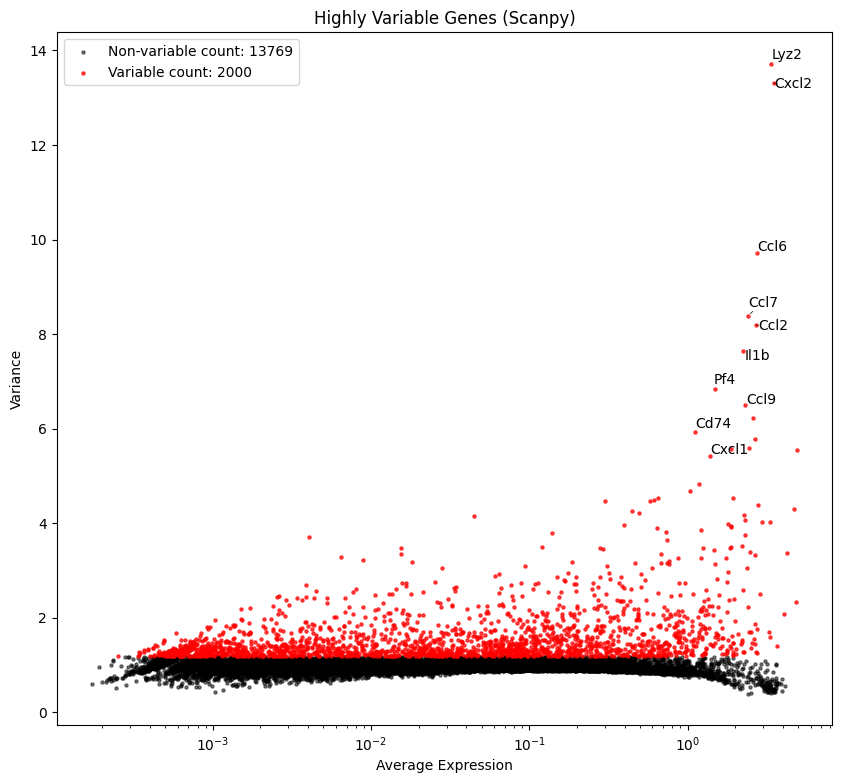

In [25]:
# Plotting HVG
means = adata.var["means"]
var = adata.var["variances_norm"]
hvg = adata.var["highly_variable"]

plt.figure(figsize=(10, 9))

# Non-variable genes
plt.scatter(means[~hvg], var[~hvg], s=5, color="black", alpha=0.5)

# HVGs
plt.scatter(means[hvg], var[hvg], s=5, color="red", alpha=0.7)

plt.xscale("log")
plt.xlabel("Average Expression")
plt.ylabel("Variance")

plt.legend([
    f"Non-variable count: {(~hvg).sum()}",
    f"Variable count: {hvg.sum()}"
])

plt.title("Highly Variable Genes (Scanpy)")

# Top genes
top_genes = adata.var[adata.var["highly_variable"]] \
    .sort_values("variances", ascending=False) \
    .head(10)

texts = []

for gene in top_genes.index:
    x = adata.var.loc[gene, "means"]
    y = adata.var.loc[gene, "variances_norm"]

    texts.append(plt.text(x, y, gene, fontsize=10))

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
)

plt.savefig("figures/hvg_scanpy_01.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# HVG
# simple list (for overlap)
pd.Series(list(scanpy_hvg)).to_csv("scanpy_hvg_01.csv", index=False, header=False)


In [39]:
# Scaling
timed("Scaling", lambda: sc.pp.scale(
    adata,
    zero_center=True,
    max_value=10
))

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Scaling: 2.44 sec


In [40]:
# PCA
timed("PCA", lambda: sc.tl.pca(
    adata,
    n_comps=50,
    use_highly_variable=True,
    svd_solver="arpack",
    random_state=42
))

/tmp/ipykernel_21369/3431463962.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  timed("PCA", lambda: sc.tl.pca(


PCA: 3.46 sec


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

loadings = adata.varm["PCs"]

# Select PC1 or PC2
pc = loadings[:, 1]
genes = adata.var_names

df = pd.DataFrame({
    "gene": genes,
    "loading": pc
})

# Top positive and negative genes
top_pos = df.sort_values("loading", ascending=False).head(10)
top_neg = df.sort_values("loading").head(10)

df_plot = pd.concat([top_pos, top_neg])

# Sort so negatives at bottom, positives at top
df_plot = df_plot.sort_values("loading")

# Plot
plt.figure(figsize=(6,5))

plt.scatter(
    df_plot["loading"],
    df_plot["gene"],
    s=60   # dot size
)

plt.axvline(0, linestyle="--")
plt.xlabel("Loading")
plt.title("PC2 Loadings")

plt.tight_layout()
plt.savefig("scanpy_01/pc2_loadings_dotplot_01.png", dpi=300)
plt.close()

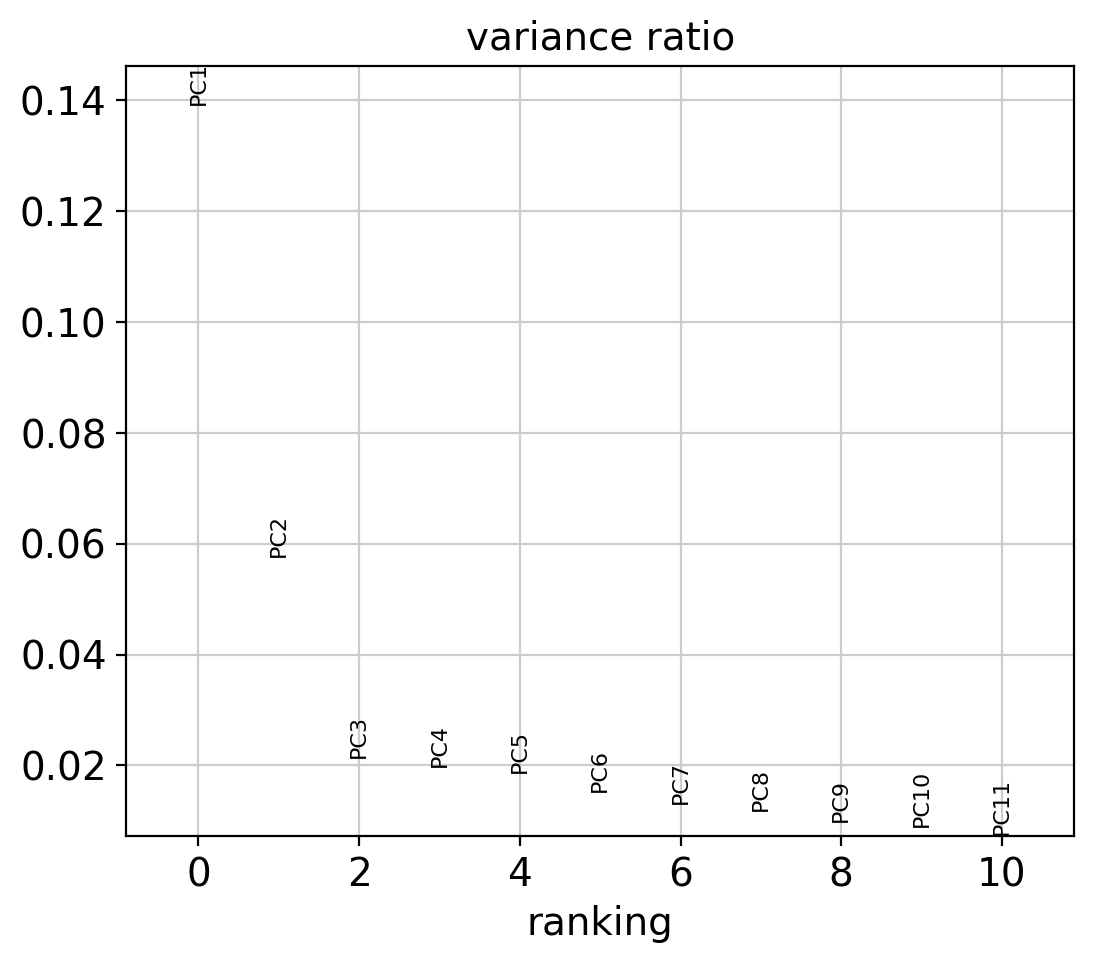

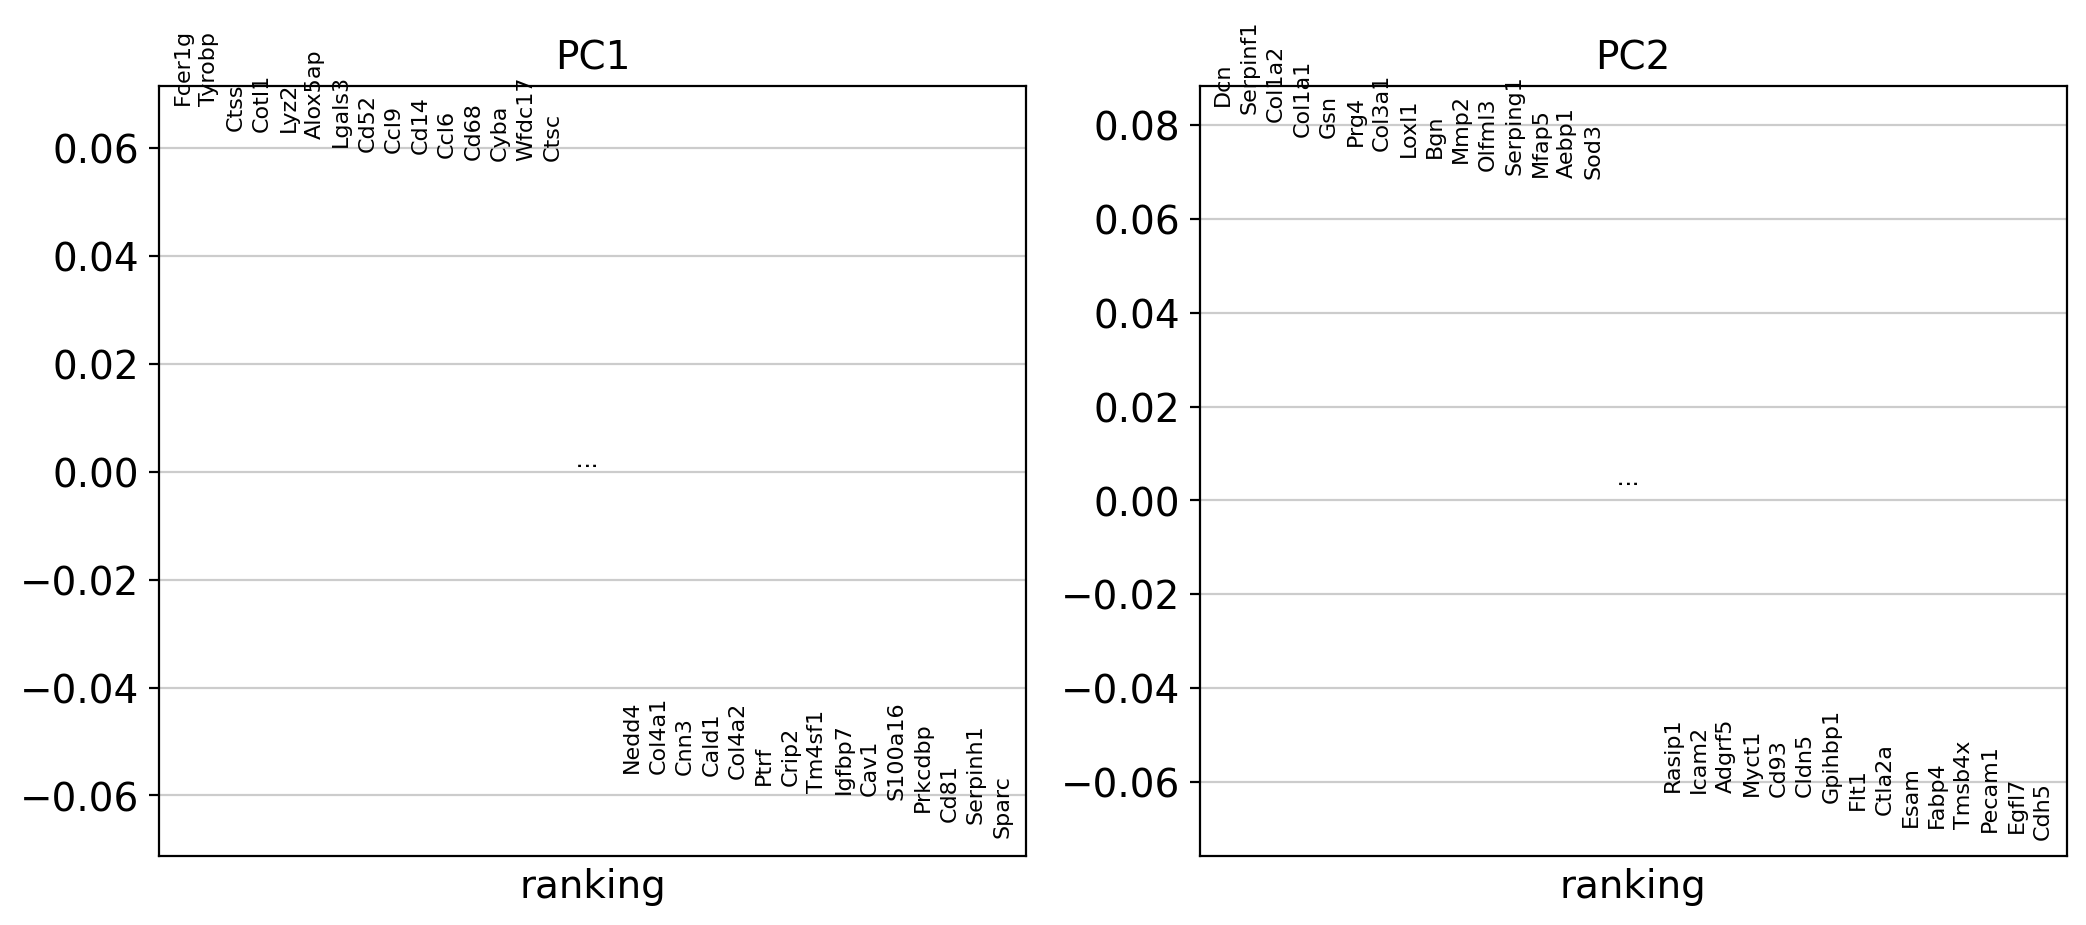

/tmp/ipykernel_21369/1536475085.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


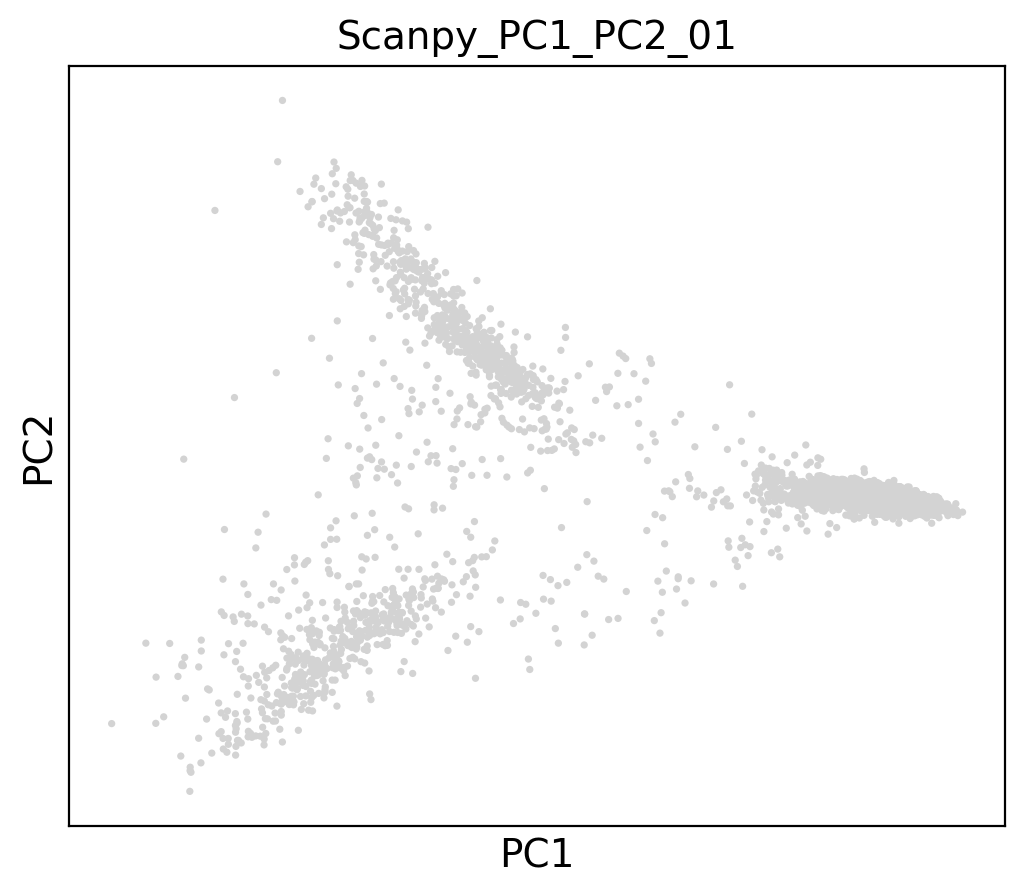

In [44]:
sc.pl.pca_variance_ratio(adata, log=False, n_pcs=10)
sc.pl.pca_loadings(adata, components="1,2")
sc.pl.pca(
    adata,
    title="Scanpy_PC1_PC2_01",
    save="_pc1_pc2_scanpy_01.png"
)



In [45]:
pca_embeddings = timed(
    "Embedding extraction",
    lambda: adata.obsm["X_pca"][:, :2]
)

pd.DataFrame(
    pca_embeddings,
    columns=["PC1", "PC2"]
).to_csv("scanpy_01/scanpy_pca_embeddings_01.csv", index=False)

Embedding extraction: 0.00 sec


In [46]:
var_explained = timed(
    "Variance explained",
    lambda: adata.uns["pca"]["variance_ratio"]
)

variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(var_explained))],
    "Variance": var_explained
})

variance_df.to_csv("scanpy_01/scanpy_variance_explained_01.csv", index=False)

Variance explained: 0.00 sec


In [47]:
loadings = timed(
    "Loadings extraction",
    lambda: adata.varm["PCs"]
)

Loadings extraction: 0.00 sec


In [48]:
def compute_top_genes():
    pc1_vals = np.abs(loadings[:, 0])
    pc2_vals = np.abs(loadings[:, 1])

    top_pc1_idx = np.argsort(pc1_vals)[::-1][:10]
    top_pc2_idx = np.argsort(pc2_vals)[::-1][:10]

    pc1_df = pd.DataFrame({
        "Gene": adata.var_names[top_pc1_idx],
        "Loading": pc1_vals[top_pc1_idx]
    })

    pc2_df = pd.DataFrame({
        "Gene": adata.var_names[top_pc2_idx],
        "Loading": pc2_vals[top_pc2_idx]
    })

    pc1_df.to_csv("scanpy_01/scanpy_pc1_genes_01.csv", index=False)
    pc2_df.to_csv("scanpy_01/scanpy_pc2_genes_01.csv", index=False)

timed("Top gene extraction", compute_top_genes)

Top gene extraction: 0.01 sec


In [54]:
timed("Neighbors", lambda: sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=10
))

Neighbors: 57.69 sec


In [57]:
timed("Clustering", lambda: sc.tl.leiden(
    adata,
    resolution=0.5
))

/tmp/ipykernel_21369/1214221455.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  timed("Clustering", lambda: sc.tl.leiden(


Clustering: 3.71 sec


In [58]:
timed("UMAP", lambda: sc.tl.umap(adata))

UMAP: 13.30 sec


In [67]:
import matplotlib.pyplot as plt

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    title="UMAP",
    frameon=True,
    show=False
)

fig = plt.gcf()
ax = fig.axes[0]

ax.invert_xaxis()

# Add labels
ax.set_xlabel("UMAP_1")
ax.set_ylabel("UMAP_2")

plt.savefig("scanpy_01/umap_scanpy_01", dpi=300, bbox_inches="tight")
plt.close()

In [71]:
pd.DataFrame(runtime_log, columns=["Step", "Time_sec"])\
  .to_csv("scanpy_01/runtime_log_scanpy_01.csv", index=False)